In [ ]:
# prompt: Split dataset with 8:2 ratio for train and test sets
from sklearn.model_selection import train_test_split

# Sample data (replace with our actual data)
X = [[1, 2], [3, 4], [5, 6], [7, 8]]  # Feature data
y = [0, 1, 0, 1]  # Target data

# Assuming 'X' is our feature data and 'y' is our target data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# X_train, y_train are our training data
# X_test, y_test are our testing data

# prompt: Apply SVM, Random forest and Logistic regression for building model (use X_train, Y-train)

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Support Vector Machine (SVM)
svm_model = SVC(kernel='linear')  # we can choose different kernels (e.g., 'rbf', 'poly')
svm_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  # Adjust n_estimators as needed
rf_model.fit(X_train, y_train)

# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Now we have trained models: svm_model, rf_model, and lr_model

# prompt: Test the models one by one on unseen data (X_test)

# Testing the SVM model
svm_predictions = svm_model.predict(X_test)

# Testing the Random Forest model
rf_predictions = rf_model.predict(X_test)

# Testing the Logistic Regression model
lr_predictions = lr_model.predict(X_test)

# Now we have predictions for each model: svm_predictions, rf_predictions, lr_predictions

# we can then evaluate the performance of each model using metrics like accuracy, precision, recall, F1-score, etc.
# For example:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, svm_predictions)
rf_accuracy = accuracy_score(y_test, rf_predictions)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("SVM Accuracy:", svm_accuracy)
print("Random Forest Accuracy:", rf_accuracy)
print("Logistic Regression Accuracy:", lr_accuracy)


LogisticRegression()

In [ ]:
# Import required libraries for splitting the dataset
from sklearn.model_selection import train_test_split

# Step 1: Prepare the feature set (X) and target variable (y)
# We will drop the 'income' column from the features and use it as the target variable
X = df.drop('income', axis=1)
y = df['income']

# Step 2: Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing sets to verify the split
print("Training set (X_train):", X_train.shape)
print("Test set (X_test):", X_test.shape)
print("Training labels (y_train):", y_train.shape)
print("Test labels (y_test):", y_test.shape)


Training set (X_train): (26048, 15)
Test set (X_test): (6513, 15)
Training labels (y_train): (26048,)
Test labels (y_test): (6513,)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

age                   0
worktype              0
fnlwt                 0
education             0
education_number      0
marital_status        0
occupation            0
relatioship_status    0
race                  0
sex                   0
capital_gain          0
capital_loss          0
native_country        0
dtype: int64
age                   0
worktype              0
fnlwt                 0
education             0
education_number      0
marital_status        0
occupation            0
relatioship_status    0
race                  0
sex                   0
capital_gain          0
capital_loss          0
native_country        0
dtype: int64
Results for SVM Model:
Accuracy: 0.8509135575003839

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.91      4942
        >50K       0.77      0.55      0.64      1571

    accuracy                           0.85      6513
   macro avg       0.82      0.75      0.77      6513
we

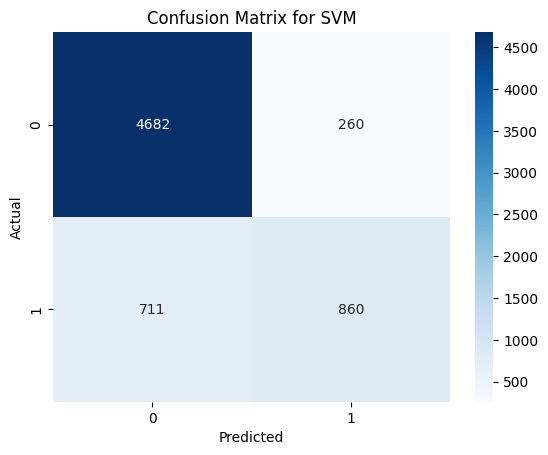

Results for Random Forest Model:
Accuracy: 0.8550591125441425

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.91      4942
        >50K       0.73      0.64      0.68      1571

    accuracy                           0.86      6513
   macro avg       0.81      0.78      0.79      6513
weighted avg       0.85      0.86      0.85      6513



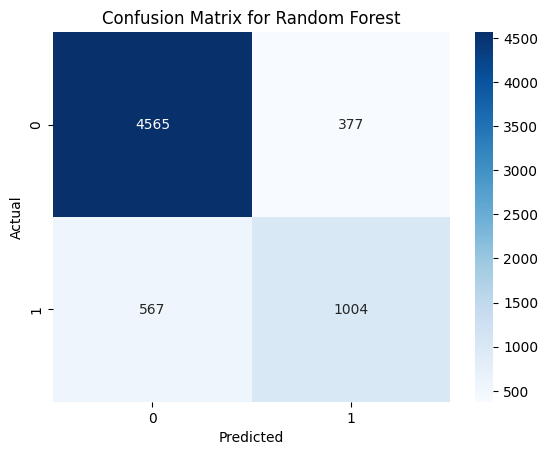

Results for Logistic Regression Model:
Accuracy: 0.8261937663135268

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.84      0.95      0.89      4942
        >50K       0.73      0.45      0.55      1571

    accuracy                           0.83      6513
   macro avg       0.79      0.70      0.72      6513
weighted avg       0.82      0.83      0.81      6513



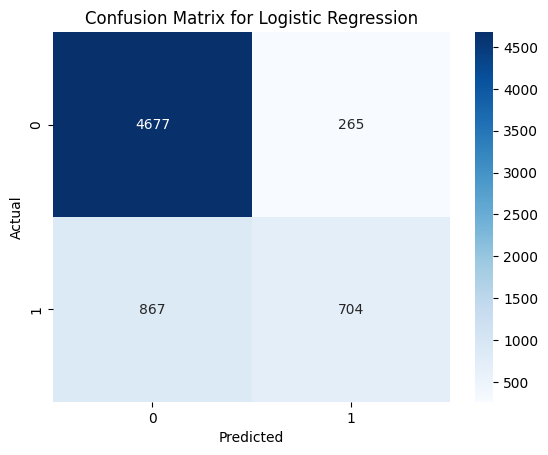

In [ ]:
# Drop the unnecessary column
X_train_df.drop(columns=['hours_per_week'], inplace=True, errors='ignore')
X_test_df.drop(columns=['hours_per_week'], inplace=True, errors='ignore')

# Check for NaNs again
print(X_train_df.isnull().sum())
print(X_test_df.isnull().sum())

# Proceed with label encoding and scaling
for col in categorical_columns:
    X_train_df[col] = label_encoder.fit_transform(X_train_df[col])
    X_test_df[col] = label_encoder.transform(X_test_df[col])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df)
X_test_scaled = scaler.transform(X_test_df)

# Fit models
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)
svm_predictions = svm_model.predict(X_test_scaled)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)

# Evaluate models
evaluate_model('SVM', y_test, svm_predictions)
evaluate_model('Random Forest', y_test, rf_predictions)
evaluate_model('Logistic Regression', y_test, lr_predictions)


Best parameters for Random Forest: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 100}
Results for Best Random Forest Model:
Accuracy: 0.8653462306156917

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      4942
        >50K       0.78      0.62      0.69      1571

    accuracy                           0.87      6513
   macro avg       0.83      0.78      0.80      6513
weighted avg       0.86      0.87      0.86      6513



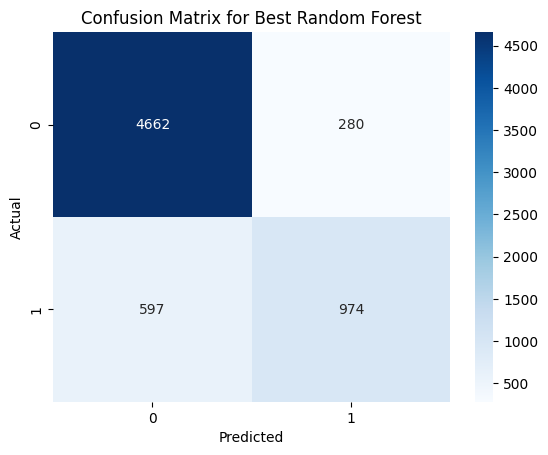

In [ ]:
from sklearn.model_selection import GridSearchCV

# Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)
print("Best parameters for Random Forest:", grid_search.best_params_)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_rf_model = RandomForestClassifier(
    max_depth=20,
    min_samples_split=10,
    n_estimators=100,
    random_state=42
)

best_rf_model.fit(X_train_scaled, y_train)
best_rf_predictions = best_rf_model.predict(X_test_scaled)

def evaluate_model(model_name, true_values, predicted_values):
    print(f"Results for {model_name} Model:")
    print("Accuracy:", accuracy_score(true_values, predicted_values))
    print("\nClassification Report:")
    print(classification_report(true_values, predicted_values))

    cm = confusion_matrix(true_values, predicted_values)
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

evaluate_model('Best Random Forest', y_test, best_rf_predictions)


In [ ]:
from sklearn.model_selection import cross_val_score

best_rf_model = RandomForestClassifier(max_depth=20, min_samples_split=10, n_estimators=100, random_state=42)
cv_scores = cross_val_score(best_rf_model, X_train_scaled, y_train, cv=5)
print("Cross-validated accuracy scores:", cv_scores)
print("Mean cross-validated accuracy:", cv_scores.mean())


Cross-validated accuracy scores: [0.85642994 0.86333973 0.8596929  0.86427337 0.86312152]
Mean cross-validated accuracy: 0.861371493086121


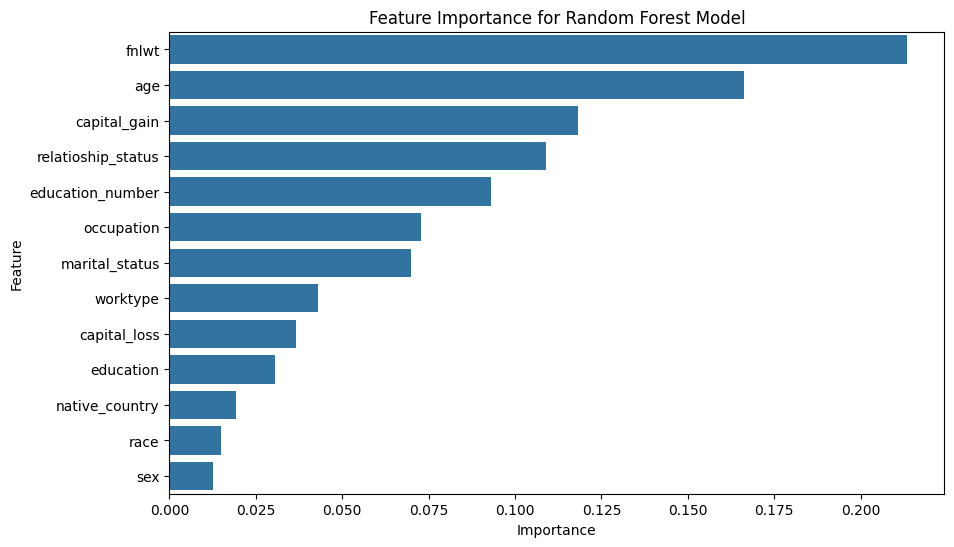

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = X_train_df.columns
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Check if "hours per week" is in the DataFrame
if 'hours per week' in feature_importance_df['Feature'].values:
    print('Hours per week is included in the feature importance.')

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance for Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


In [ ]:
# Select a single row from the dataset using NumPy indexing
sample_input = X_test[0:1]

# Ensure the input has the same number of columns as the training data by selecting relevant columns
# Align the sample input to match the columns in X_train_df
sample_input_aligned = sample_input[:, :len(X_train_df.columns)]

# Convert the NumPy array to a DataFrame for easier handling
sample_df = pd.DataFrame(sample_input_aligned, columns=X_train_df.columns)

# Scale the input using the same scaler used for training
sample_scaled = scaler.transform(sample_df)

# Make a prediction
prediction = best_rf_model.predict(sample_scaled)

# Display the prediction
income_class = '<=50K' if prediction[0] == 0 else '>50K'
print(f'The predicted income for the selected input is: {income_class}')


The predicted income for the selected input is: >50K
